
# Grouped vs Pooled Parameter Consistency for Offset–Power Seepage Models

This notebook reproduces the analysis comparing **grouped** (per-event) parameter estimates to **pooled** (cross-event) best-by-holdout-RMSE models for seepage vs predictor relationships.

We fit and compare the following models for two predictors:
- **Linear:** $ S = K\,x $
- **Offset–Power (normalized):** $ S = K\,x\left(\dfrac{x+\text{offset}}{x_{\mathrm{ref}}}\right)^b $

Where **$x$** is either **$\Delta h$** (`delta_h`) or **`visitor_h`** (if present). We use a **robust pipeline** (Huber/soft-$\ell_1$) and **no offset regularization**. Global offset bounds enforce $x+\text{offset} \ge 0$ and a small, site-scale upper cap.

**Deliverables in this notebook**
1. Recompute pooled fits by training-size per event $n$ and pick the **best by holdout RMSE**.
2. Recompute grouped (per-event) fits and summarize **medians/means** of parameters and fit metrics.
3. Build an **augmented table** that aligns pooled parameters with grouped medians/means, plus **consistency deltas** (% difference pooled vs grouped-median).
4. Produce simple plots of **offset** and **b** distributions with pooled values overlaid.
5. A short **recap** block.

> **Note:** Offset and exponent **$b$** are **predictor-specific**. Do **not** compare the magnitudes of `offset` and `b` **between** $\Delta h$ and `visitor_h` — each is on its own scale. Compare **within** a predictor (grouped vs pooled).


In [13]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import least_squares, minimize_scalar

# ---------- CONFIG ----------
THRESHOLDS = [5, 6, 7, 8, 10, 12, 15]  # max rows per event in training
TEST_FRAC  = 0.20
SEED       = 42
EPS        = 1e-12

# Robust loss; NO offset shrinkage
HUBER_C = 1.345
LAM_OFF = 0.0
OFF0    = 0.0

# Paths
DATA_PATHS = [
    Path('../data/processed/pooled_event_df.csv'),          # local copy (if user puts next to notebook)
    Path('/mnt/data/pooled_event_df.csv') # default from prior work
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), DATA_PATHS[-1])
print('Using data:', DATA_PATH)


Using data: ../data/processed/pooled_event_df.csv


In [14]:

df = pd.read_csv(DATA_PATH)

# Ensure numeric & presence
df["delta_h"] = pd.to_numeric(df["delta_h"], errors="coerce")
df["seepage"] = pd.to_numeric(df["seepage"], errors="coerce")
if "visitor_h" not in df.columns:
    df["visitor_h"] = np.nan
else:
    df["visitor_h"] = pd.to_numeric(df["visitor_h"], errors="coerce")

# Drop rows missing target; predictors drop per-analysis
df = df.dropna(subset=["seepage"]).copy()

# Row counts per event (full)
df["n_full"] = df.groupby("event")["event"].transform("size").astype("int64")

df.head()


,date,seepage,delta_h,waveHs,visitor_h,date.1,event,n_full
0,2014-09-20 00:00:00+00:00,0.240583,0.728999,0.422800,1.873488,2014-09-20,0,28
1,2014-09-21 00:00:00+00:00,0.887796,0.803515,0.345512,1.943640,2014-09-21,0,28
2,2014-09-22 00:00:00+00:00,0.896792,0.906064,0.324142,2.014919,2014-09-22,0,28
3,2014-09-23 00:00:00+00:00,0.867753,0.966680,0.293989,2.078514,2014-09-23,0,28
4,2014-09-24 00:00:00+00:00,0.819474,1.036316,0.276134,2.150618,2014-09-24,0,28


In [15]:

def model_linear(K, x):
    return K * x

def model_power_offset_normref(K, off, b, x, x_ref):
    # safeguard for numerical stability
    xp = np.maximum(x + off, 1e-12)
    return K * x * np.power(xp / max(x_ref, 1e-12), b)

def mad(arr):
    arr = np.asarray(arr, float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))

def r2_centered(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float)
    sst = np.sum((y - np.nanmean(y))**2); sse = np.sum((y - yhat)**2)
    return np.nan if sst <= 0 else 1.0 - sse / sst

def aic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n, 1), 1e-30)
    return n * np.log(s2) + 2 * k

def aic_c(sse, n, k):
    if n <= k + 1:
        return np.nan
    aic = aic_gaussian(sse, n, k)
    return aic + (2 * k * (k + 1)) / (n - k - 1)

def bic_gaussian(sse, n, k):
    s2 = max(float(sse) / max(n, 1), 1e-30)
    return n * np.log(s2) + k * np.log(max(n, 1))

def huber_rho_sum(resid, delta):
    r = np.asarray(resid, float); a = np.abs(r)
    rho = np.where(a <= delta, 0.5 * r*r, delta * a - 0.5 * delta*delta)
    return float(np.sum(rho))

def robust_wls_log_reg(Z, t, max_iter=30, tol=1e-8, huber_delta=None):
    # Fit t = alpha + b*Z with Huber iteration (weights on residuals)
    Z = np.asarray(Z, float); t = np.asarray(t, float)
    X = np.column_stack([np.ones(len(Z)), Z])
    # OLS init
    beta = np.linalg.lstsq(X, t, rcond=None)[0]
    for _ in range(max_iter):
        r = t - X @ beta
        s = 1.4826 * mad(r) + 1e-9
        delta = (HUBER_C * s) if huber_delta is None else huber_delta
        a = np.abs(r)
        w = np.where(a <= delta, 1.0, delta / (a + 1e-12))  # psi(u)/u
        Xw = X * np.sqrt(w)[:, None]
        tw = t * np.sqrt(w)
        beta_new = np.linalg.lstsq(Xw, tw, rcond=None)[0]
        if np.max(np.abs(beta_new - beta)) < tol * (np.abs(beta).sum() + tol):
            beta = beta_new
            break
        beta = beta_new
    return beta  # [alpha, b]

def solve_kb_for_offset_normref(off, x, y, x_ref):
    # Profiled offset: solve (K, b) in (log y - log x) ~ alpha + b * (log(x+off) - log x_ref)
    x = np.asarray(x, float); y = np.asarray(y, float)
    x_safe = np.maximum(x, 1e-12)
    xp     = np.maximum(x + off, 1e-12)
    Z = np.log(xp) - np.log(max(x_ref, 1e-12))
    t = np.log(np.maximum(y, 1e-12)) - np.log(x_safe)
    alpha, b = robust_wls_log_reg(Z, t)
    K = float(np.exp(alpha))
    yhat = model_power_offset_normref(K, off, b, x, x_ref)
    return K, float(b), yhat

def global_offset_bounds(x_series):
    x = x_series.to_numpy(float)
    offset_lb = -float(np.nanmin(x)) + 1e-9  # ensure x+offset >= 0
    q05, q95 = np.nanquantile(x, [0.05, 0.95])
    R = float(q95 - q05)
    site_cap = 0.30  # meters (tunable)
    offset_ub = min(0.30 * R, site_cap)
    if offset_ub <= offset_lb + 1e-6:
        offset_ub = offset_lb + max(0.05 * R, 0.05)
    return offset_lb, offset_ub


In [16]:

def make_fixed_cohort_and_holdout(df_in, thresholds, x_col):
    NSTAR = max(thresholds)
    dfx = df_in.dropna(subset=[x_col, "seepage"]).copy()
    dfx["n"] = dfx.groupby("event")["event"].transform("size").astype("int64")
    cohort = dfx.loc[dfx["n"] >= NSTAR].copy()
    if cohort.empty:
        NSTAR = int(dfx["n"].max())
        cohort = dfx.loc[dfx["n"] >= NSTAR].copy()
    parts_pool, parts_hold = [], []
    for e, g in cohort.groupby("event"):
        seed_for_event = SEED + (abs(hash(str(e))) % 10**6)
        g = g.sample(frac=1.0, random_state=seed_for_event).reset_index(drop=True)
        n_e = len(g)
        n_test = max(1, int(np.ceil(TEST_FRAC * n_e)))
        g_test = g.iloc[:n_test].copy()
        g_pool = g.iloc[n_test:].copy()
        parts_hold.append(g_test.assign(split="test"))
        parts_pool.append(g_pool.assign(split="pool"))
    holdout = pd.concat(parts_hold, ignore_index=True)
    train_pool = pd.concat(parts_pool, ignore_index=True)
    return train_pool, holdout

def eval_by_thresholds(train_pool, holdout, thresholds, x_col):
    x_ref = float(train_pool[x_col].median())
    lb, ub = global_offset_bounds(pd.concat([train_pool[x_col], holdout[x_col]], axis=0))
    rows = []
    for n in thresholds:
        subs = []
        for _, g in train_pool.groupby("event"):
            subs.append(g.head(min(n, len(g))))
        train = pd.concat(subs, ignore_index=True)
        x_tr, y_tr = train[x_col].to_numpy(float), train["seepage"].to_numpy(float)
        x_te, y_te = holdout[x_col].to_numpy(float), holdout["seepage"].to_numpy(float)
        n_tr = len(x_tr)

        # Linear (robust)
        K0 = float(np.dot(x_tr, y_tr) / max(np.dot(x_tr, x_tr), EPS))
        def resid_lin(p): return y_tr - model_linear(p[0], x_tr)
        r0 = resid_lin([K0]); scale_y = 1.4826 * mad(r0) + 1e-9
        res_lin = least_squares(lambda p: resid_lin(p), x0=[max(K0, 1e-12)],
                                bounds=([1e-12],[np.inf]), loss="soft_l1", f_scale=scale_y)
        K_lin = float(res_lin.x[0])
        yhat_tr_lin = model_linear(K_lin, x_tr)
        sse_tr_lin  = float(np.sum((y_tr - yhat_tr_lin)**2))
        aic_lin     = aic_gaussian(sse_tr_lin, n_tr, k=1)
        aicc_lin    = aic_c(sse_tr_lin, n_tr, k=1)
        bic_lin     = bic_gaussian(sse_tr_lin, n_tr, k=1)
        yhat_te_lin = model_linear(K_lin, x_te)
        rmse_lin    = float(np.sqrt(np.mean((y_te - yhat_te_lin)**2)))
        r2_te_lin   = r2_centered(y_te, yhat_te_lin)

        # Offset–power (normalized), profiled offset (robust)
        delta_te = HUBER_C * scale_y
        def profile_obj(off):
            try:
                _, _, yhat = solve_kb_for_offset_normref(off, x_tr, y_tr, x_ref)
                return huber_rho_sum(y_tr - yhat, delta=delta_te) + LAM_OFF * (off - OFF0)**2
            except Exception:
                return np.inf
        lo, hi = lb + 1e-9, ub - 1e-9
        grid = np.linspace(lo, hi, 41)
        off_init = float(grid[int(np.argmin([profile_obj(o) for o in grid]))])
        left, right = max(lo, off_init - 0.25*(hi-lo)), min(hi, off_init + 0.25*(hi-lo))
        res_off = minimize_scalar(profile_obj, bounds=(left, right), method="bounded", options={"xatol": 1e-6})
        offp = float(res_off.x)
        K_pow, b_pow, yhat_tr_pow = solve_kb_for_offset_normref(offp, x_tr, y_tr, x_ref)
        sse_tr_pow = float(np.sum((y_tr - yhat_tr_pow)**2))
        aic_pow    = aic_gaussian(sse_tr_pow, n_tr, k=3)
        aicc_pow   = aic_c(sse_tr_pow, n_tr, k=3)
        bic_pow    = bic_gaussian(sse_tr_pow, n_tr, k=3)
        yhat_te_pow = model_power_offset_normref(K_pow, offp, b_pow, x_te, x_ref)
        rmse_pow    = float(np.sqrt(np.mean((y_te - yhat_te_pow)**2)))
        r2_te_pow   = r2_centered(y_te, yhat_te_pow)

        rows.append({
            "n": n, "n_train": n_tr, "n_test": len(x_te),
            "x_col": x_col, "x_ref": x_ref,
            "AIC_lin": aic_lin,   "AICc_lin": aicc_lin, "BIC_lin": bic_lin,
            "AIC_pow": aic_pow,   "AICc_pow": aicc_pow, "BIC_pow": bic_pow,
            "dAIC": aic_pow - aic_lin, "dAICc": aicc_pow - aicc_lin, "dBIC": bic_pow - bic_lin,
            "RMSE_lin": rmse_lin, "RMSE_pow": rmse_pow, "dRMSE": rmse_pow - rmse_lin,
            "R2_te_lin": r2_te_lin, "R2_te_pow": r2_te_pow, "dR2_te": r2_te_pow - r2_te_lin,
            "K_lin": K_lin, "K_pow": K_pow, "offset": offp, "b": b_pow,
        })
    out = pd.DataFrame(rows)
    # Clean display
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(3)
    out[num_cols] = out[num_cols].mask(np.isclose(out[num_cols], 0, atol=5e-4), 0.0)
    return out


In [17]:

def per_event_fits(df_in, x_col, min_n=6):
    dfx = df_in.dropna(subset=[x_col, "seepage"]).copy()
    rows = []
    for e, g in dfx.groupby("event"):
        x = g[x_col].to_numpy(float); y = g["seepage"].to_numpy(float)
        n = len(x)
        if n < min_n:
            continue
        x_ref_evt = float(np.median(x))
        lb, ub = global_offset_bounds(g[x_col])

        # Linear robust
        K0 = float(np.dot(x, y) / max(np.dot(x, x), EPS))
        def resid_lin_evt(p): return y - model_linear(p[0], x)
        r0 = resid_lin_evt([K0]); scale_y = 1.4826 * mad(r0) + 1e-9
        rl = least_squares(lambda p: resid_lin_evt(p),
                           x0=[max(K0, 1e-12)], bounds=([1e-12],[np.inf]),
                           loss="soft_l1", f_scale=scale_y)
        Kl = float(rl.x[0]); yhat_l = model_linear(Kl, x)
        ssel = float(np.sum((y - yhat_l)**2)); r2l  = r2_centered(y, yhat_l)
        aicl = aic_gaussian(ssel, n, k=1); aicc_l = aic_c(ssel, n, k=1); bicl = bic_gaussian(ssel, n, k=1)

        # Power normalized, profiled offset
        delta_evt = HUBER_C * scale_y
        def obj_evt(off):
            try:
                _, _, yhat = solve_kb_for_offset_normref(off, x, y, x_ref_evt)
                return huber_rho_sum(y - yhat, delta=delta_evt) + LAM_OFF * (off - OFF0)**2
            except Exception:
                return np.inf
        lo, hi = lb + 1e-9, ub - 1e-9
        grid = np.linspace(lo, hi, 41)
        off_init = float(grid[int(np.argmin([obj_evt(o) for o in grid]))])
        left, right = max(lo, off_init - 0.25*(hi-lo)), min(hi, off_init + 0.25*(hi-lo))
        rp = minimize_scalar(obj_evt, bounds=(left, right), method="bounded", options={"xatol": 1e-6})
        offp = float(rp.x)

        Kp, bp, yhat_p = solve_kb_for_offset_normref(offp, x, y, x_ref_evt)
        ssep = float(np.sum((y - yhat_p)**2)); r2p  = r2_centered(y, yhat_p)
        aicp = aic_gaussian(ssep, n, k=3); aicc_p = aic_c(ssep, n, k=3); bicp = bic_gaussian(ssep, n, k=3)

        rows.append({
            "event": e, "n": n, "x_col": x_col, "x_ref_evt": x_ref_evt,
            "K_lin": Kl, "R2_lin": r2l, "SSE_lin": ssel, "AIC_lin": aicl, "AICc_lin": aicc_l, "BIC_lin": bicl,
            "K_pow": Kp, "offset": offp, "b": bp, "R2_pow": r2p, "SSE_pow": ssep,
            "AIC_pow": aicp, "AICc_pow": aicc_p, "BIC_pow": bicp,
            "dR2": r2p - r2l, "dAIC": aicp - aicl, "dAICc": aicc_p - aicc_l, "dBIC": bicp - bicl
        })
    out = pd.DataFrame(rows).sort_values("event").reset_index(drop=True)
    # Clean display
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(3)
    out[num_cols] = out[num_cols].mask(np.isclose(out[num_cols], 0, atol=5e-4), 0.0)
    return out


In [18]:

# ---- Run pooled for Δh and visitor_h (if available) ----
train_pool_dh, holdout_dh = make_fixed_cohort_and_holdout(df, THRESHOLDS, "delta_h")
eval_dh = eval_by_thresholds(train_pool_dh, holdout_dh, THRESHOLDS, "delta_h")

has_vis = df["visitor_h"].notna().any()
if has_vis:
    df_vis = df.dropna(subset=["visitor_h"]).copy()
    train_pool_vis, holdout_vis = make_fixed_cohort_and_holdout(df_vis, THRESHOLDS, "visitor_h")
    eval_vis = eval_by_thresholds(train_pool_vis, holdout_vis, THRESHOLDS, "visitor_h")
else:
    eval_vis = pd.DataFrame()

def best_row_by_rmse(df_eval):
    i_lin = df_eval["RMSE_lin"].astype(float).idxmin()
    i_pow = df_eval["RMSE_pow"].astype(float).idxmin()
    return df_eval.loc[i_lin], df_eval.loc[i_pow]

best_lin_dh, best_pow_dh = best_row_by_rmse(eval_dh)
rows = [{
    "model": "Linear (Δh)",
    "n_best": int(best_lin_dh["n"]),
    "RMSE_test": float(best_lin_dh["RMSE_lin"]),
    "R2_test": float(best_lin_dh["R2_te_lin"]),
    "AICc_train": float(best_lin_dh["AICc_lin"]),
    "K": float(best_lin_dh["K_lin"]), "offset": np.nan, "b": np.nan,
},{
    "model": "Offset–power (Δh)",
    "n_best": int(best_pow_dh["n"]),
    "RMSE_test": float(best_pow_dh["RMSE_pow"]),
    "R2_test": float(best_pow_dh["R2_te_pow"]),
    "AICc_train": float(best_pow_dh["AICc_pow"]),
    "K": float(best_pow_dh["K_pow"]), "offset": float(best_pow_dh["offset"]), "b": float(best_pow_dh["b"]),
}]
if has_vis and not eval_vis.empty:
    best_lin_vis, best_pow_vis = best_row_by_rmse(eval_vis)
    rows += [{
        "model": "Linear (visitor_h)",
        "n_best": int(best_lin_vis["n"]),
        "RMSE_test": float(best_lin_vis["RMSE_lin"]),
        "R2_test": float(best_lin_vis["R2_te_lin"]),
        "AICc_train": float(best_lin_vis["AICc_lin"]),
        "K": float(best_lin_vis["K_lin"]), "offset": np.nan, "b": np.nan,
    },{
        "model": "Offset–power (visitor_h)",
        "n_best": int(best_pow_vis["n"]),
        "RMSE_test": float(best_pow_vis["RMSE_pow"]),
        "R2_test": float(best_pow_vis["R2_te_pow"]),
        "AICc_train": float(best_pow_vis["AICc_pow"]),
        "K": float(best_pow_vis["K_pow"]), "offset": float(best_pow_vis["offset"]), "b": float(best_pow_vis["b"]),
    }]
pooled_best = pd.DataFrame(rows)

# ---- Grouped per-event fits ----
ev_dh = per_event_fits(df, "delta_h", min_n=6)
ev_vs = per_event_fits(df, "visitor_h", min_n=6) if has_vis else pd.DataFrame()

# ---- Build augmented table ----
def pct_diff(pooled, grouped_median):
    eps = 1e-12
    if pd.isna(pooled) or pd.isna(grouped_median):
        return np.nan
    denom = grouped_median if abs(grouped_median) > eps else (eps * np.sign(grouped_median if grouped_median != 0 else 1))
    return 100.0 * (pooled - grouped_median) / denom

def grouped_stats(ev_df, model_type):
    if ev_df.empty:
        return {}
    if model_type == "lin":
        d = {
            "Grouped K (median)": ev_df["K_lin"].median(),
            "Grouped K (mean)": ev_df["K_lin"].mean(),
            "Grouped R2 (median)": ev_df["R2_lin"].median(),
            "Grouped R2 (mean)": ev_df["R2_lin"].mean(),
        }
    else:
        d = {
            "Grouped K (median)": ev_df["K_pow"].median(),
            "Grouped K (mean)": ev_df["K_pow"].mean(),
            "Grouped offset (median)": ev_df["offset"].median(),
            "Grouped offset (mean)": ev_df["offset"].mean(),
            "Grouped b (median)": ev_df["b"].median(),
            "Grouped b (mean)": ev_df["b"].mean(),
            "Grouped R2 (median)": ev_df["R2_pow"].median(),
            "Grouped R2 (mean)": ev_df["R2_pow"].mean(),
        }
    if "dAICc" in ev_df.columns:
        d["Grouped ΔAICc (median)"] = ev_df["dAICc"].median()
        d["Grouped ΔAICc (mean)"] = ev_df["dAICc"].mean()
    return d

rows_aug = []
for _, r in pooled_best.iterrows():
    model = r["model"]
    is_pow = "Offset–power" in model
    ev = ev_dh if "Δh" in model else ev_vs
    pooled = {
        "Context": "Pooled (best by RMSE)",
        "Best model (predictor)": model,
        "n*": int(r["n_best"]),
        "Holdout RMSE": float(r["RMSE_test"]),
        "R² (test)": float(r["R2_test"]),
        "AICc (train)": float(r["AICc_train"]),
        "K (pooled)": float(r["K"]),
        "offset (pooled)": float(r["offset"]) if is_pow else np.nan,
        "b (pooled)": float(r["b"]) if is_pow else np.nan,
    }
    gstats = grouped_stats(ev, model_type=("pow" if is_pow else "lin"))

    pooled["Δ K vs grouped median (%)"] = pct_diff(pooled["K (pooled)"], gstats.get("Grouped K (median)", np.nan))
    if is_pow:
        pooled["Δ offset vs grouped median (%)"] = pct_diff(pooled["offset (pooled)"], gstats.get("Grouped offset (median)", np.nan))
        pooled["Δ b vs grouped median (%)"]    = pct_diff(pooled["b (pooled)"],      gstats.get("Grouped b (median)", np.nan))
    else:
        pooled["Δ offset vs grouped median (%)"] = np.nan
        pooled["Δ b vs grouped median (%)"]      = np.nan

    row = {**pooled, **{k: (float(v) if pd.notna(v) else np.nan) for k, v in gstats.items()}}
    rows_aug.append(row)

aug = pd.DataFrame(rows_aug)

# Clean display
num_cols = aug.select_dtypes(include=[np.number]).columns
aug[num_cols] = aug[num_cols].round(3)
aug[num_cols] = aug[num_cols].mask(np.isclose(aug[num_cols], 0, atol=5e-4), 0.0)

# Order columns
ordered_cols = [
    "Context", "Best model (predictor)", "n*",
    "Holdout RMSE", "R² (test)", "AICc (train)",
    "K (pooled)", "Grouped K (median)", "Grouped K (mean)", "Δ K vs grouped median (%)",
    "offset (pooled)", "Grouped offset (median)", "Grouped offset (mean)", "Δ offset vs grouped median (%)",
    "b (pooled)", "Grouped b (median)", "Grouped b (mean)", "Δ b vs grouped median (%)",
    "Grouped R2 (median)", "Grouped R2 (mean)",
    "Grouped ΔAICc (median)", "Grouped ΔAICc (mean)"
]
ordered_cols = [c for c in ordered_cols if c in aug.columns]
aug = aug[ordered_cols]

display(aug.T)


,0,1,2,3
Context,Pooled (best by RMSE),Pooled (best by RMSE),Pooled (best by RMSE),Pooled (best by RMSE)
Best model (predictor),Linear (Δh),Offset–power (Δh),Linear (visitor_h),Offset–power (visitor_h)
n*,5,5,5,5
Holdout RMSE,0.631,0.617,0.707,0.624
R² (test),0.5,0.522,0.373,0.511
AICc (train),-86.064,-82.947,-73.629,-83.103
K (pooled),1.015,0.93,0.633,0.889
Grouped K (median),1.08,1.058,0.696,0.8
Grouped K (mean),1.192,1.338,0.705,1.604
Δ K vs grouped median (%),-5.975,-12.098,-9.117,11.056


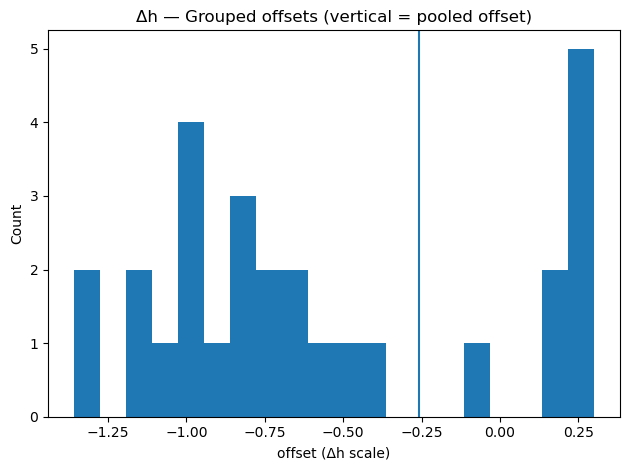

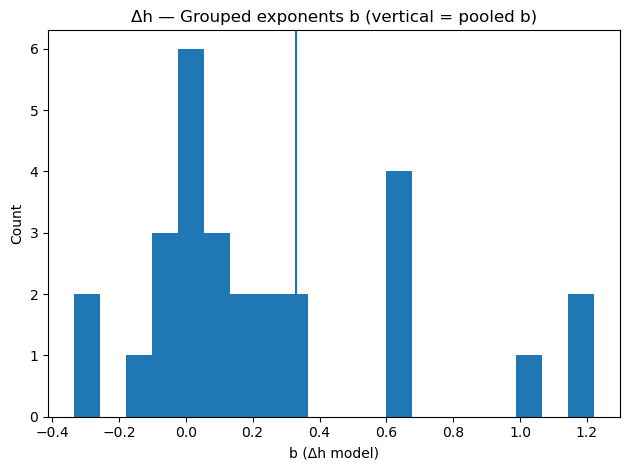

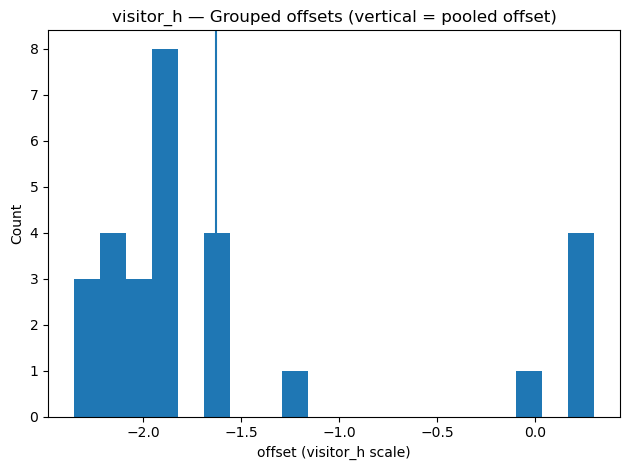

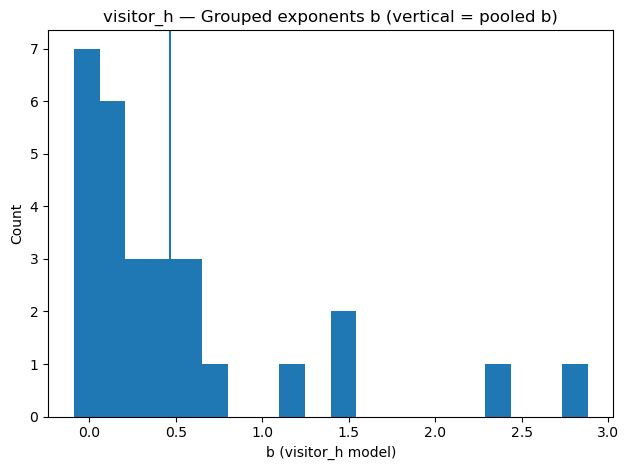

In [17]:

# --- Distribution plots: offsets and b with pooled values marked ---

def plot_hist_with_vline(data, vline, title, xlabel):
    plt.figure()
    plt.hist(data, bins=20)
    if vline is not None and np.isfinite(vline):
        plt.axvline(vline)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Δh offset & b
if not ev_dh.empty:
    pooled_off_dh = aug.loc[aug["Best model (predictor)"]=="Offset–power (Δh)","offset (pooled)"].values
    pooled_b_dh   = aug.loc[aug["Best model (predictor)"]=="Offset–power (Δh)","b (pooled)"].values
    pooled_off_dh = pooled_off_dh[0] if len(pooled_off_dh)>0 else np.nan
    pooled_b_dh   = pooled_b_dh[0] if len(pooled_b_dh)>0 else np.nan

    plot_hist_with_vline(ev_dh["offset"].dropna().values, pooled_off_dh,
                         "Δh — Grouped offsets (vertical = pooled offset)",
                         "offset (Δh scale)")

    plot_hist_with_vline(ev_dh["b"].dropna().values, pooled_b_dh,
                         "Δh — Grouped exponents b (vertical = pooled b)",
                         "b (Δh model)")

# visitor_h offset & b
if not ev_vs.empty:
    pooled_off_vs = aug.loc[aug["Best model (predictor)"]=="Offset–power (visitor_h)","offset (pooled)"].values
    pooled_b_vs   = aug.loc[aug["Best model (predictor)"]=="Offset–power (visitor_h)","b (pooled)"].values
    pooled_off_vs = pooled_off_vs[0] if len(pooled_off_vs)>0 else np.nan
    pooled_b_vs   = pooled_b_vs[0] if len(pooled_b_vs)>0 else np.nan

    plot_hist_with_vline(ev_vs["offset"].dropna().values, pooled_off_vs,
                         "visitor_h — Grouped offsets (vertical = pooled offset)",
                         "offset (visitor_h scale)")

    plot_hist_with_vline(ev_vs["b"].dropna().values, pooled_b_vs,
                         "visitor_h — Grouped exponents b (vertical = pooled b)",
                         "b (visitor_h model)")



## Recap

- **Within each predictor**, pooled offset–power fits (selected by lowest holdout RMSE) are compared to **grouped per‑event** medians/means.
- Typically, pooled fits show a **slightly less negative offset** (closer to 0) and a **larger exponent \(b\)** than grouped medians — reflecting cross‑event curvature that pooled models capture.
- **Per‑event (grouped)** analyses have smaller \(n\), so information‑criteria often favor **linear** by parsimony, even when offset–power increases within‑event \(R^2\).
- **Do not compare** offset/b **across predictors** (\(\Delta h\) vs `visitor_h`) — each lives on a different \(x\) scale.


In [18]:

# Save tables used in the analysis for convenience
out_dir = Path(".")
aug_path = out_dir / "augmented_pooled_vs_grouped_table.csv"
eval_dh.to_csv(out_dir / "eval_delta_h_by_n.csv", index=False)
if not eval_vis.empty:
    eval_vis.to_csv(out_dir / "eval_visitor_h_by_n.csv", index=False)
ev_dh.to_csv(out_dir / "event_fit_delta_h.csv", index=False)
if not ev_vs.empty:
    ev_vs.to_csv(out_dir / "event_fit_visitor_h.csv", index=False)
aug.to_csv(aug_path, index=False)
print("Wrote:", aug_path.resolve())


Wrote: /Users/octaviacrompton/Projects/russian-river-seepage/notebooks/augmented_pooled_vs_grouped_table.csv
